2D Helmholtz Equation - Finite Difference Method Solver

Problem Parameters:
  Domain: [-1.0, 1.0] × [-1.0, 1.0]
  Grid points: 31 × 31 = 961
  Grid spacing: Δx = 0.0667, Δy = 0.0667
  Wave number k²: 1+0j
  Mode numbers: m = 1, n = 1
  Eigenvalue λ: 4.9348

Solving 2D Helmholtz equation...
Solving linear system of size 961×961...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.
Solution computed successfully!
  Solution range (Re): [-0.7526, 0.0000]

Evaluation Metrics (on grid):
----------------------------------------
  MSE            : 7.757337e-08
  RMSE           : 2.785200e-04
  MAE            : 2.375110e-04
  MAX_ERROR      : 4.937009e-04
  RELATIVE_L2    : 6.962485e-04

Generating visualization plots...


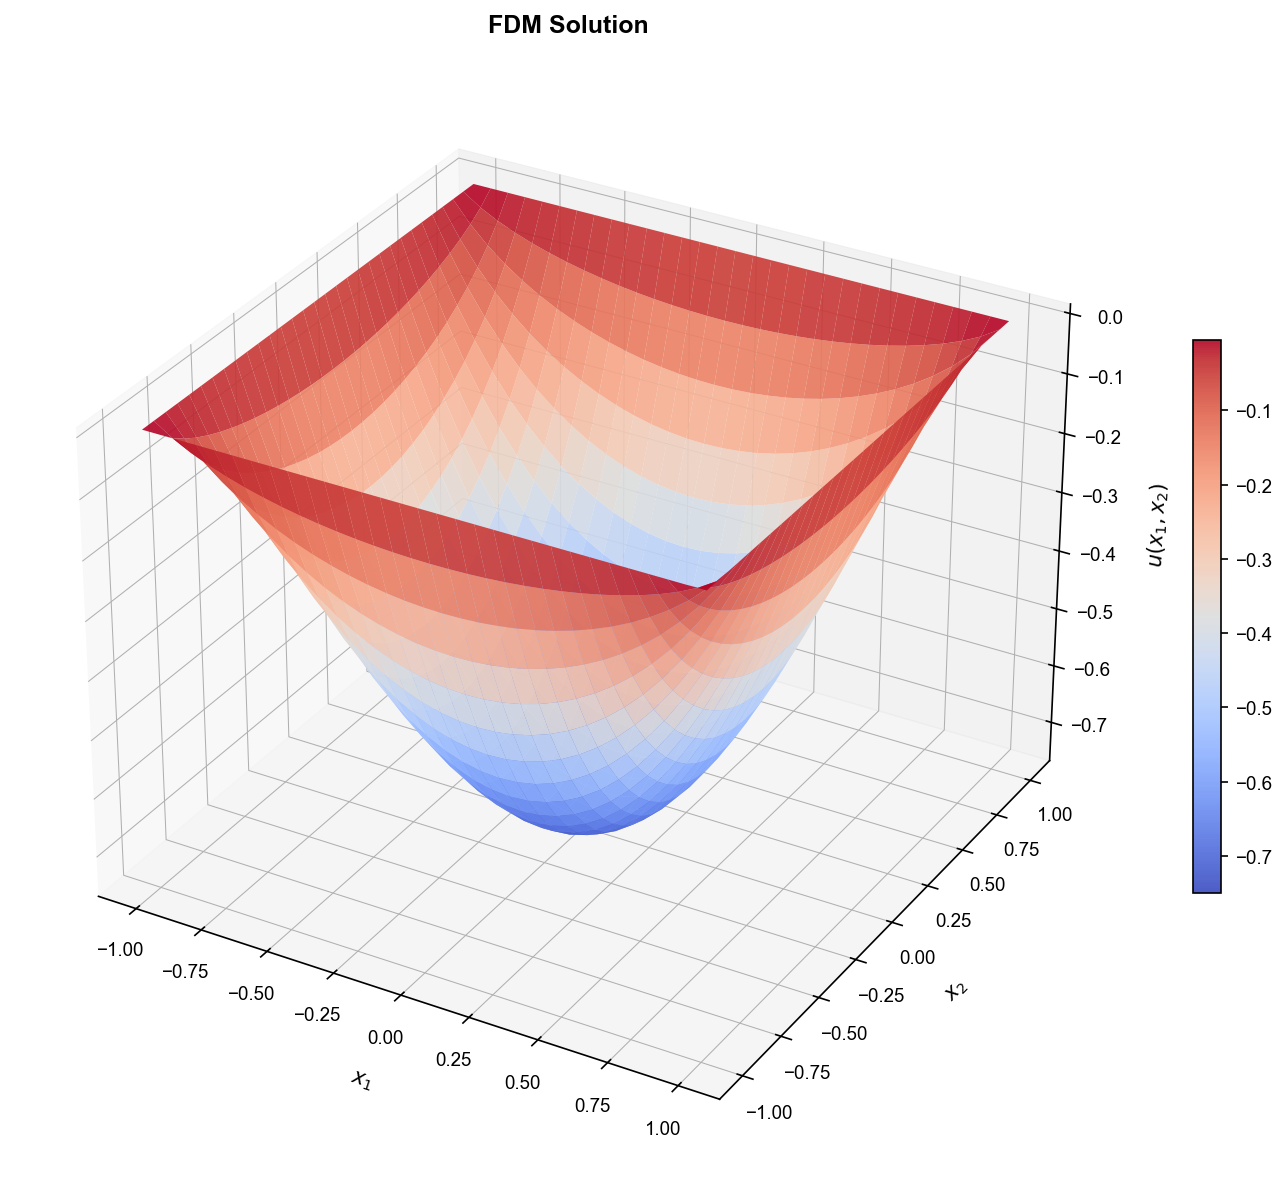

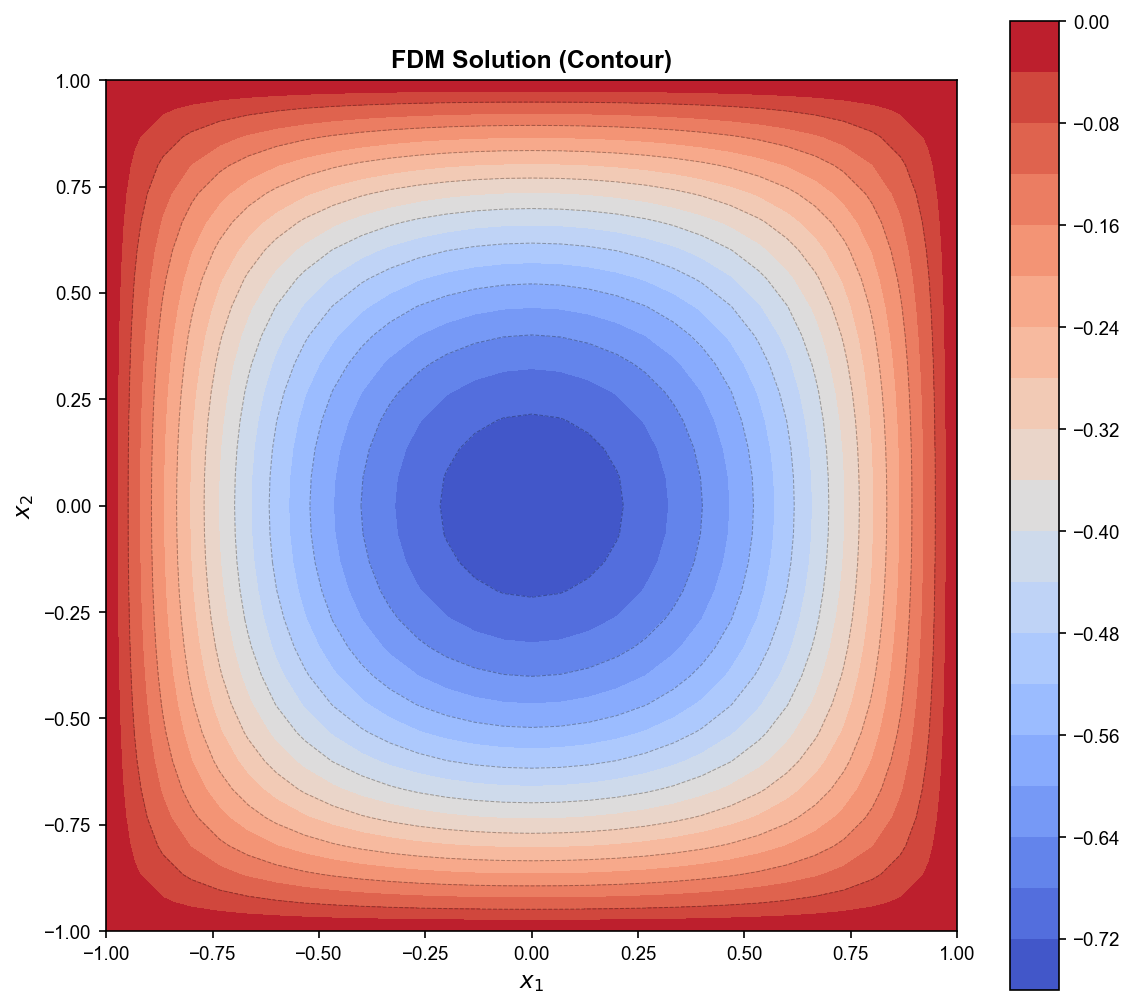

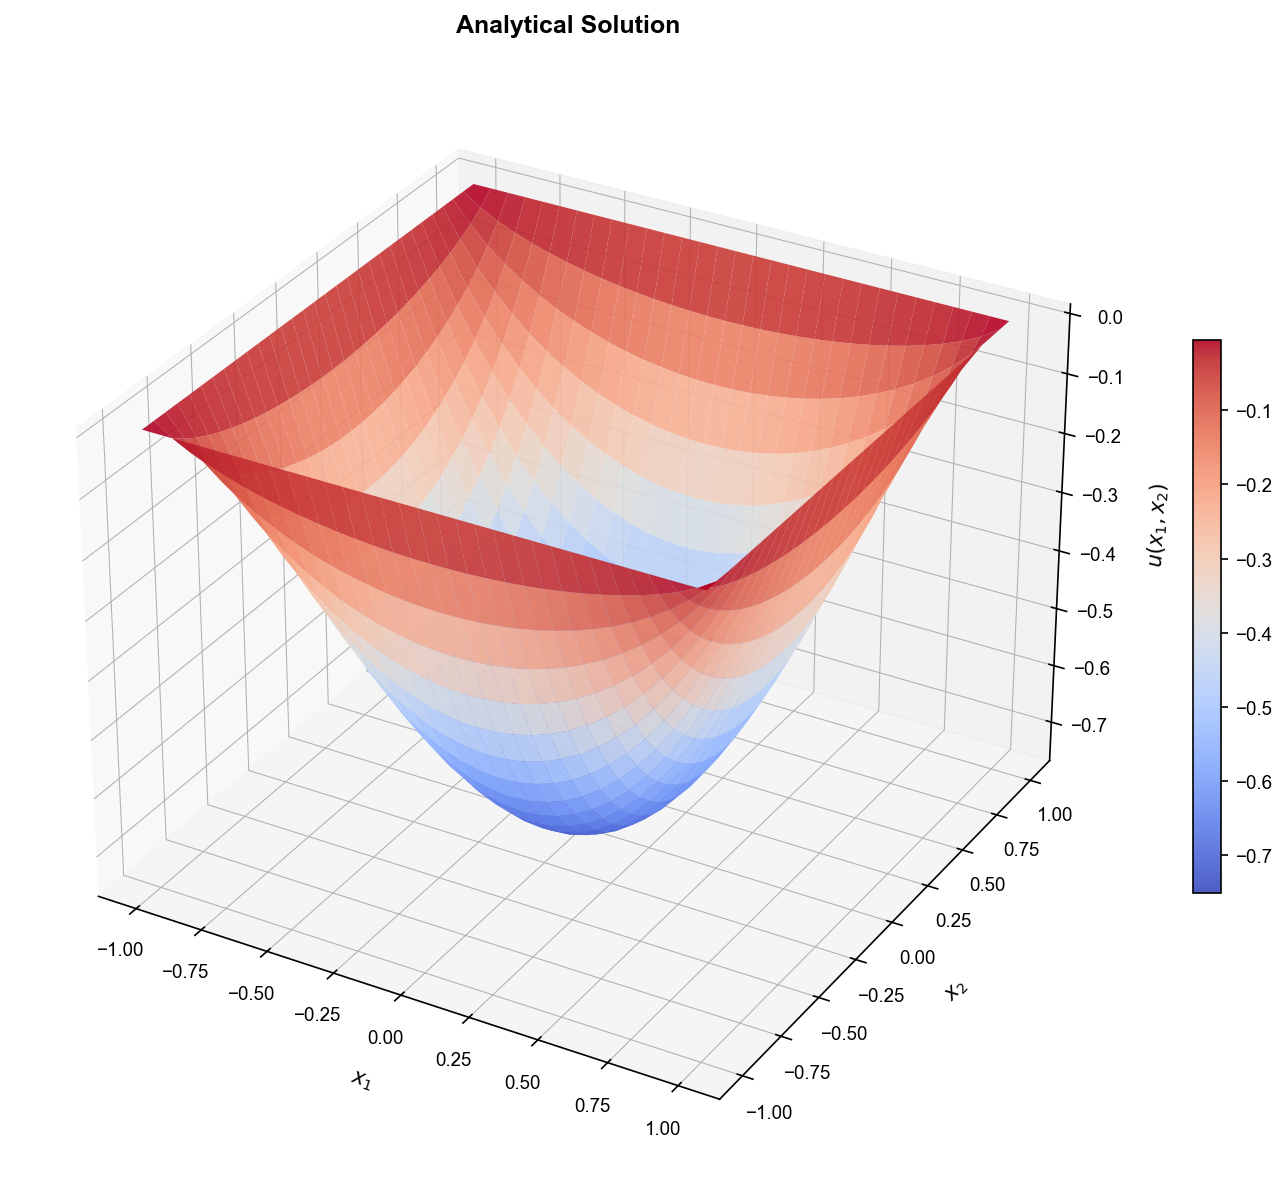

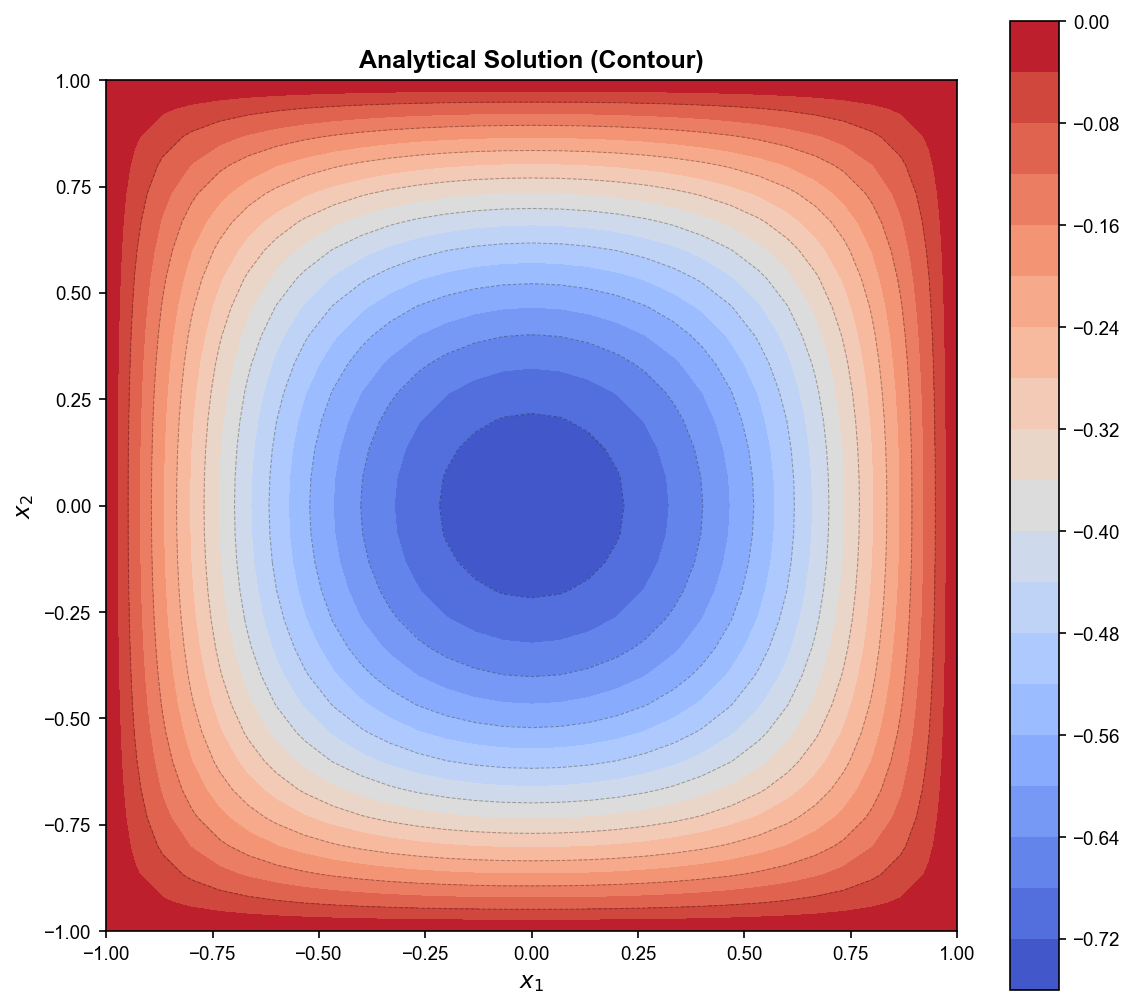

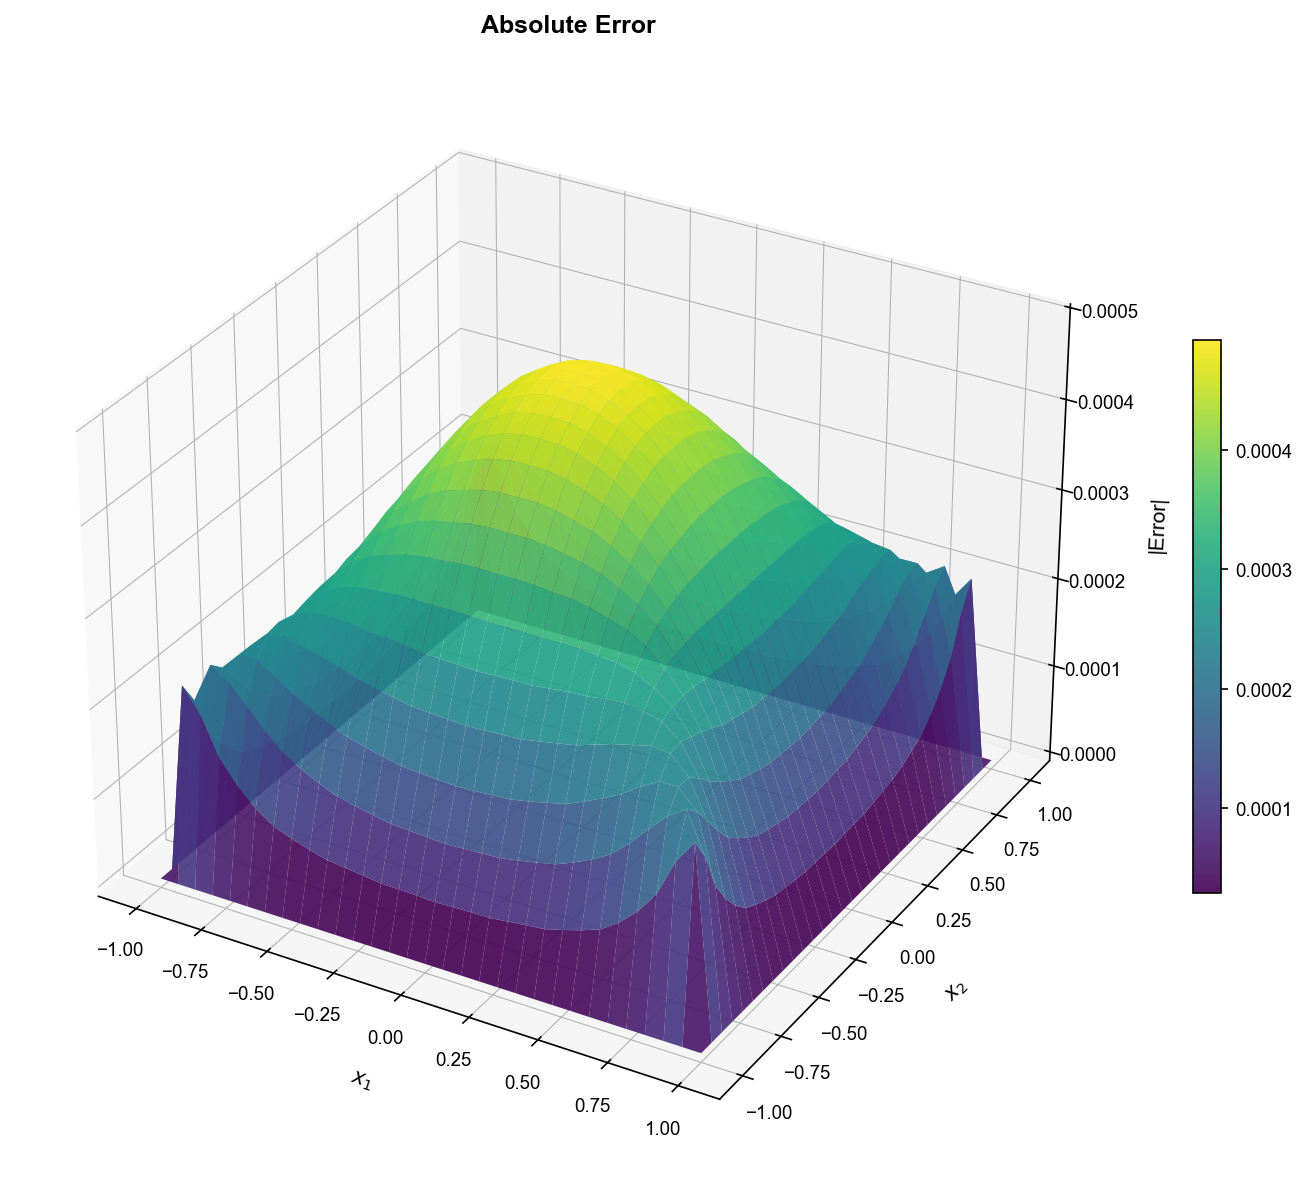

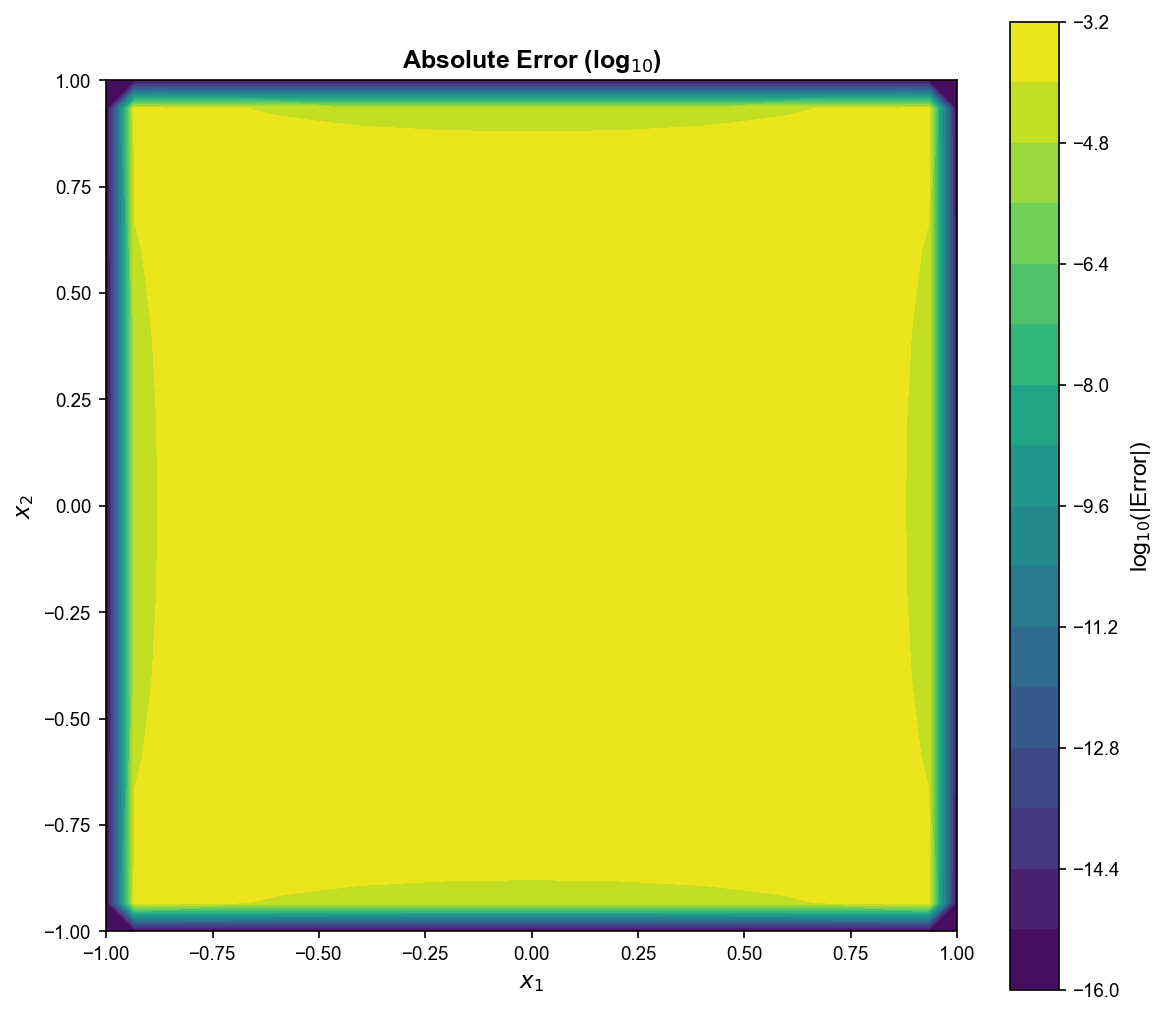


Performing convergence study...

Testing grid: 11 × 11
Solving linear system of size 121×121...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.

Testing grid: 21 × 21
Solving linear system of size 441×441...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.

Testing grid: 41 × 41
Solving linear system of size 1681×1681...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.

Testing grid: 81 × 81
Solving linear system of size 6561×6561...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.

Testing grid: 101 × 101
Solving linear system of size 10201×10201...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part for further analysis.


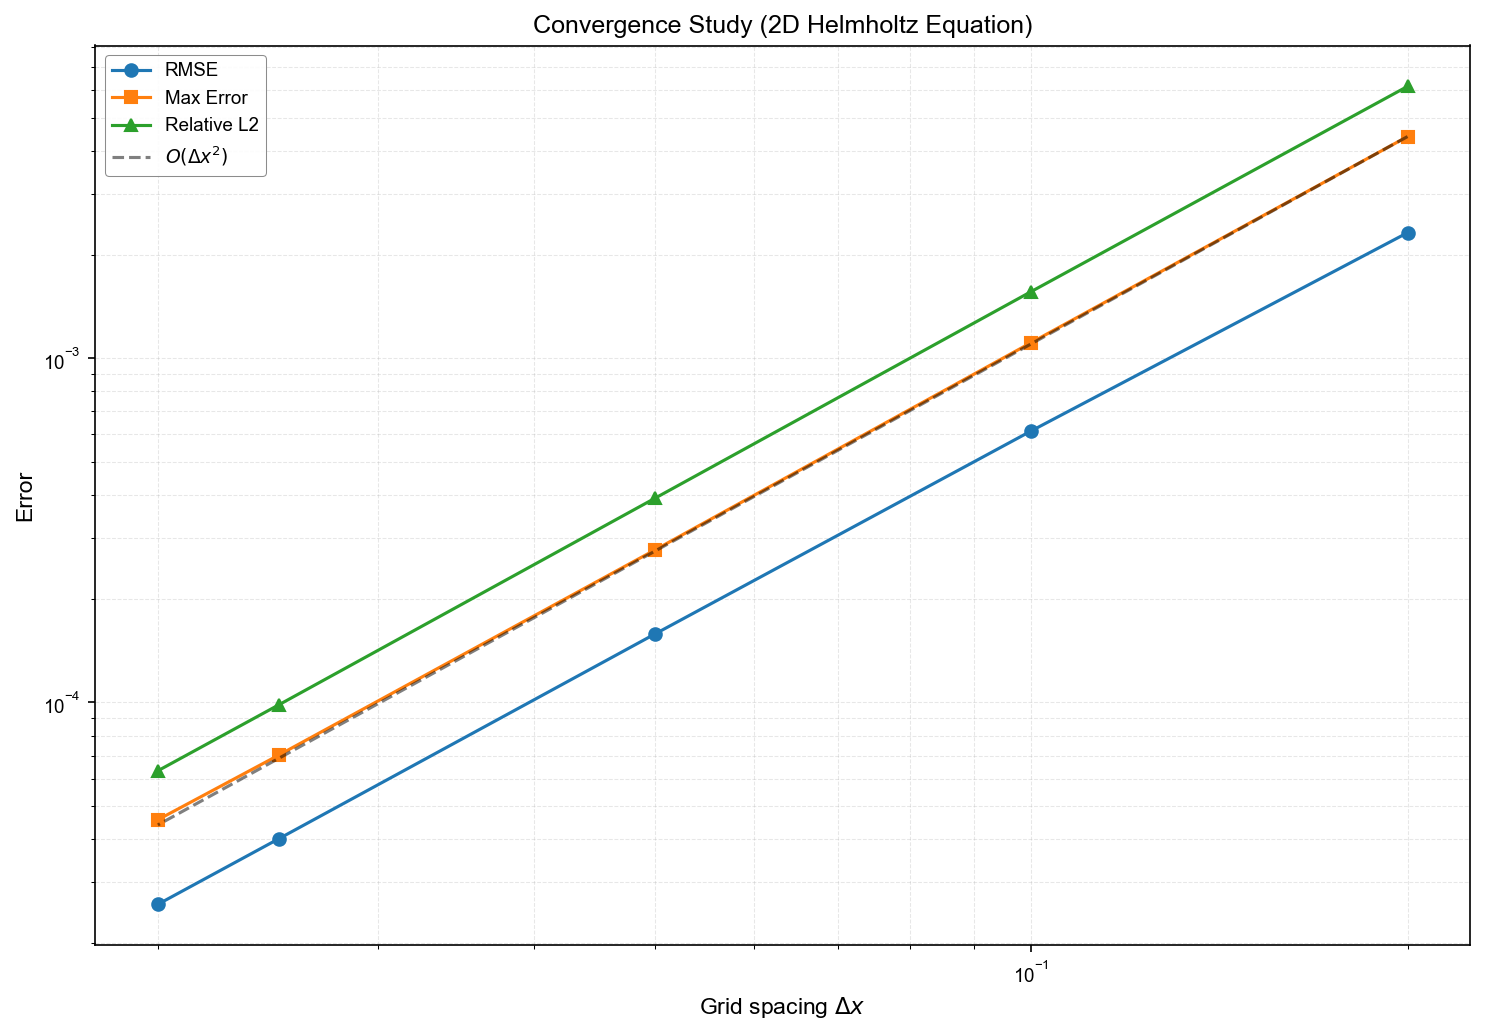


Convergence Results:
      Grid Size           Δx           RMSE      Max Error
----------------------------------------------------------------------
     11 × 11         0.20000   2.314196e-03   4.403365e-03
     21 × 21         0.10000   6.148173e-04   1.110207e-03
     41 × 41         0.05000   1.580805e-04   2.774237e-04
     81 × 81         0.02500   4.017055e-05   7.030643e-05
    101 × 101        0.02000   2.588850e-05   4.558351e-05

Estimated convergence rate: 1.99 (theoretical: 2.00)



In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec, patches
from typing import Dict, List, Tuple, Optional, Callable
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_diverging = 'coolwarm'  # for solution
cmap_uncertainty = 'viridis'  # for error/uncertainty

class HelmholtzFDMSolver2D:
    r"""
    Finite Difference Method solver for 2D inhomogeneous Helmholtz equation

        (∇² + k²) u(x, y) = f(x, y)    on [a,b] × [c,d]

    with Dirichlet boundary conditions:

        u(x, y) = g(x, y)              on ∂([a,b] × [c,d]).

    By default, this class sets up a mathematically consistent benchmark problem:

    - Domain:      [a,b] × [c,d]  (default [-1,1] × [-1,1])
    - Analytic u:  sine–sine eigenfunction that vanishes on the boundary
    - Source f:    chosen so that the analytic u satisfies (∇² + k²)u = f
    - BC g:        equal to the analytic u on the boundary

    This yields a fully consistent PDE + BC + source triple; the finite-difference
    scheme can thus be rigorously validated via convergence studies.
    """

    def __init__(
        self,
        domain: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, 1.0), (-1.0, 1.0)),
        n_points: Tuple[int, int] = (51, 51),
        source_func: Optional[Callable[[np.ndarray, np.ndarray], np.ndarray]] = None,
        analytical_solution: Optional[Callable[[np.ndarray, np.ndarray], np.ndarray]] = None,
        G_prime: float = 1.0,
        G_double_prime: float = 0.0,
        rho: float = 1.0,
        omega: float = 1.0,
        mode_numbers: Tuple[int, int] = (1, 1),
        use_analytical_bc: bool = True,
    ):
        """
        Initialize the 2D FDM solver.

        Args
        ----
        domain:
            Computational domain ((x_min, x_max), (y_min, y_max)).
        n_points:
            Number of grid points (n_x, n_y).
        source_func:
            Source term function f(x,y) taking meshgrid arrays (X, Y).
            If None *and* analytical_solution is None, a consistent benchmark
            source is constructed automatically.
        analytical_solution:
            Analytical solution u(x,y) for comparison and BC, taking meshgrid
            arrays (X, Y). If None, a sine–sine eigenfunction is used.
            If you supply your own analytical_solution, you must also supply a
            consistent source_func or the PDE will not be guaranteed to match.
        G_prime:
            Storage modulus (real part of shear modulus).
        G_double_prime:
            Loss modulus (imaginary part of shear modulus).
        rho:
            Density.
        omega:
            Angular frequency.
        mode_numbers:
            Tuple (m, n) of positive integers for the sine–sine mode used in the
            default benchmark analytical solution.
        use_analytical_bc:
            If True, Dirichlet BC are enforced using analytical_solution on the
            boundary. If False, homogeneous BC u=0 are used.
        """
        self.domain = domain
        self.n_points = n_points
        self.G_prime = G_prime
        self.G_double_prime = G_double_prime
        self.rho = rho
        self.omega = omega
        self.mode_m, self.mode_n = mode_numbers
        self.use_analytical_bc = use_analytical_bc

        # Grid dimensions
        self.nx, self.ny = n_points
        self.n_total = self.nx * self.ny

        # Wave number k^2 from viscoelastic parameters
        self.k_squared = self._compute_wave_number()

        # Precompute eigenvalue λ for the default sine–sine mode
        self.lambda_eig = self._compute_mode_eigenvalue()

        # Analytical solution
        if analytical_solution is None:
            self.analytical_solution = self._default_analytical_solution
            default_analytic = True
        else:
            self.analytical_solution = analytical_solution
            default_analytic = False

        # Source function
        if source_func is None and default_analytic:
            # Consistent source for the default benchmark:
            # (∇² + k²) u = (-λ + k²) u
            self.source_func = self._default_source_func
        elif source_func is None and not default_analytic:
            raise ValueError(
                "If you provide a custom analytical_solution, "
                "you must also provide a consistent source_func."
            )
        else:
            self.source_func = source_func

        # Setup grid arrays
        self._setup_grid()

        # Solution placeholder
        self.u_solution: Optional[np.ndarray] = None

    # ------------------------------------------------------------------
    # Core problem definition
    # ------------------------------------------------------------------

    def _compute_wave_number(self) -> complex:
        """Compute the wave number squared k² = ρ ω² / (G' + i G'')."""
        return (self.rho * self.omega ** 2) / (self.G_prime + 1j * self.G_double_prime)

    def _compute_mode_eigenvalue(self) -> float:
        """
        Compute λ for the sine–sine eigenfunction on the given domain:

            u(x,y) = sin(π m (x-a)/(b-a)) sin(π n (y-c)/(d-c))

        which satisfies ∇² u = -λ u.
        """
        (a, b), (c, d) = self.domain
        m, n = self.mode_m, self.mode_n
        lam = (np.pi * m / (b - a)) ** 2 + (np.pi * n / (d - c)) ** 2
        return lam

    def _default_analytical_solution(self, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
        """
        Default analytical solution:

            u(x,y) = sin(π m (x-a)/(b-a)) sin(π n (y-c)/(d-c)),

        which vanishes on the entire boundary of [a,b] × [c,d].
        """
        (a, b), (c, d) = self.domain
        m, n = self.mode_m, self.mode_n

        xi = (X - a) / (b - a)
        eta = (Y - c) / (d - c)

        return np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta)

    def _default_source_func(self, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
        """
        Default source term f(x,y) for the benchmark:

            (∇² + k²) u = f,  with  ∇² u = -λ u

        so

            f(x,y) = (-λ + k²) u(x,y).

        This guarantees that the analytical solution satisfies the PDE exactly
        in the interior for any (possibly complex) k².
        """
        u = self._default_analytical_solution(X, Y)
        return (-self.lambda_eig + self.k_squared) * u

    # ------------------------------------------------------------------
    # Grid & index helpers
    # ------------------------------------------------------------------

    def _setup_grid(self) -> None:
        """Setup the 2D computational grid."""
        x_min, x_max = self.domain[0]
        y_min, y_max = self.domain[1]

        self.x = np.linspace(x_min, x_max, self.nx)
        self.y = np.linspace(y_min, y_max, self.ny)
        self.X, self.Y = np.meshgrid(self.x, self.y, indexing="ij")

        self.dx = (x_max - x_min) / (self.nx - 1)
        self.dy = (y_max - y_min) / (self.ny - 1)

    def _get_index(self, i: int, j: int) -> int:
        """Convert 2D grid indices (i,j) to 1D linear index (row-major)."""
        return i * self.ny + j

    def _is_boundary(self, i: int, j: int) -> bool:
        """Check if grid point (i,j) is on the boundary."""
        return i == 0 or i == self.nx - 1 or j == 0 or j == self.ny - 1

    # ------------------------------------------------------------------
    # System assembly
    # ------------------------------------------------------------------

    def build_system(self) -> Tuple[csr_matrix, np.ndarray]:
        r"""
        Build the linear system A u = b for the 2D FDM discretization.

        For interior nodes (i,j), we use the standard 5-point stencil for the
        isotropic Laplacian with possibly dx ≠ dy:

            (u_{i-1,j} - 2u_{i,j} + u_{i+1,j}) / dx² +
            (u_{i,j-1} - 2u_{i,j} + u_{i,j+1}) / dy² + k² u_{i,j} = f_{i,j}.

        This gives the row:

            (1/dx²) * u_{i-1,j}
          + (1/dx²) * u_{i+1,j}
          + (1/dy²) * u_{i,j-1}
          + (1/dy²) * u_{i,j+1}
          + [-2(1/dx² + 1/dy²) + k²] * u_{i,j} = f_{i,j}.
        """
        n = self.n_total
        dx2 = self.dx ** 2
        dy2 = self.dy ** 2

        # Evaluate source function on grid
        f_grid = self.source_func(self.X, self.Y)

        # Decide dtype based on k² and f
        complex_problem = np.iscomplexobj(self.k_squared) or np.iscomplexobj(f_grid)
        dtype = complex if complex_problem else float

        # Use lil_matrix for efficient construction
        A = lil_matrix((n, n), dtype=dtype)
        b = np.zeros(n, dtype=dtype)

        for i in range(self.nx):
            for j in range(self.ny):
                idx = self._get_index(i, j)

                if self._is_boundary(i, j):
                    # Dirichlet boundary condition
                    A[idx, idx] = 1.0
                    if self.use_analytical_bc and self.analytical_solution is not None:
                        # Enforce u = u_analytical on the boundary
                        u_bc = self.analytical_solution(
                            np.array([[self.x[i]]]), np.array([[self.y[j]]])
                        )[0, 0]
                        b[idx] = u_bc
                    else:
                        # Homogeneous BC u = 0
                        b[idx] = 0.0
                else:
                    # Interior node: 5-point stencil for (∇² + k²)u = f
                    center_coeff = -2.0 * (1.0 / dx2 + 1.0 / dy2) + self.k_squared
                    A[idx, idx] = center_coeff

                    # Left neighbor
                    idx_left = self._get_index(i - 1, j)
                    A[idx, idx_left] = 1.0 / dx2

                    # Right neighbor
                    idx_right = self._get_index(i + 1, j)
                    A[idx, idx_right] = 1.0 / dx2

                    # Bottom neighbor
                    idx_bottom = self._get_index(i, j - 1)
                    A[idx, idx_bottom] = 1.0 / dy2

                    # Top neighbor
                    idx_top = self._get_index(i, j + 1)
                    A[idx, idx_top] = 1.0 / dy2

                    # Right-hand side (no scaling)
                    b[idx] = f_grid[i, j]

        # Convert to CSR format for efficient solving
        A = A.tocsr()
        return A, b

    # ------------------------------------------------------------------
    # Solving & prediction
    # ------------------------------------------------------------------

    def solve(self) -> np.ndarray:
        """
        Solve the 2D Helmholtz equation using FDM.

        Returns
        -------
        u_solution : np.ndarray
            Numerical solution as a 2D array of shape (nx, ny).
        """
        A, b = self.build_system()

        print(f"Solving linear system of size {self.n_total}×{self.n_total}...")
        u_flat = spsolve(A, b)
        self.u_solution = u_flat.reshape((self.nx, self.ny))

        # If the theoretical solution is real-valued, any imaginary part
        # should be pure numerical noise. Report it but do not silently
        # discard it unless it is negligible.
        if np.iscomplexobj(self.u_solution):
            max_imag = np.max(np.abs(np.imag(self.u_solution)))
            print(f"Note: Solution is complex. Max |Im(u)| = {max_imag:.2e}")
            if max_imag < 1e-12:
                print("Imaginary part is negligible; using real part for further analysis.")
                self.u_solution = np.real(self.u_solution)

        return self.u_solution

    def predict(self, X_test: np.ndarray, Y_test: np.ndarray) -> np.ndarray:
        """
        Interpolate solution at test points using spline interpolation.

        Args
        ----
        X_test:
            X coordinates (1D or 2D array).
        Y_test:
            Y coordinates (same shape as X_test).

        Returns
        -------
        u_pred : np.ndarray
            Interpolated solution values, same shape as X_test.
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet. Call solve() first.")

        from scipy.interpolate import RectBivariateSpline

        # Interpolate the (possibly real) solution.
        # For this benchmark the analytical solution is real; if the user
        # wants to interpolate a genuinely complex solution, they can do
        # so separately on real/imag parts.
        u_real = np.real(self.u_solution)
        interpolator = RectBivariateSpline(self.x, self.y, u_real)

        X_flat = X_test.flatten()
        Y_flat = Y_test.flatten()
        u_pred_flat = np.array([interpolator(x, y)[0, 0] for x, y in zip(X_flat, Y_flat)])
        return u_pred_flat.reshape(X_test.shape)

    # ------------------------------------------------------------------
    # Metrics & plotting
    # ------------------------------------------------------------------

    def compute_metrics(
        self,
        X_test: Optional[np.ndarray] = None,
        Y_test: Optional[np.ndarray] = None,
        metrics: Optional[List[str]] = None,
    ) -> Dict[str, float]:
        """
        Compute evaluation metrics comparing the FDM solution with the analytical solution.

        If X_test and Y_test are None, metrics are computed directly on the grid
        using the raw FDM solution (no interpolation), which is the most precise
        setup for convergence studies.
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet. Call solve() first.")

        if metrics is None:
            metrics = ["mse", "rmse", "mae", "max_error", "relative_l2"]

        if X_test is None or Y_test is None:
            # Use grid points and raw solution
            u_pred = self.u_solution.flatten()
            u_true = self.analytical_solution(self.X, self.Y).flatten()
        else:
            u_pred = self.predict(X_test, Y_test).flatten()
            u_true = self.analytical_solution(X_test, Y_test).flatten()

        # Use magnitude of complex differences if needed
        diff = u_true - u_pred

        def mse(y_true, y_pred):
            return np.mean(np.abs(y_true - y_pred) ** 2)

        def rmse(y_true, y_pred):
            return np.sqrt(mse(y_true, y_pred))

        def mae(y_true, y_pred):
            return np.mean(np.abs(y_true - y_pred))

        def max_error(y_true, y_pred):
            return np.max(np.abs(y_true - y_pred))

        def r2(y_true, y_pred):
            num = np.sum(np.abs(y_true - y_pred) ** 2)
            den = np.sum(np.abs(y_true - np.mean(y_true)) ** 2)
            return 1.0 - num / den

        def relative_l2(y_true, y_pred):
            return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

        metric_functions = {
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "max_error": max_error,
            "r2": r2,
            "relative_l2": relative_l2,
        }

        results: Dict[str, float] = {}
        for name in metrics:
            if name in metric_functions:
                results[name] = float(metric_functions[name](u_true, u_pred))
            else:
                print(f"Warning: Metric '{name}' not implemented")

        return results

    def plot_solution(self, save_path: Optional[str] = None, show_plot: bool = True):
        """
        Plot the 2D FDM solution, analytical solution, and error as separate figures.

        Uses the current grid.
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet. Call solve() first.")

        u_analytical = self.analytical_solution(self.X, self.Y)
        error = np.abs(self.u_solution - u_analytical)

        figures = []

        # 1. FDM Solution - Surface plot
        fig1 = plt.figure(figsize=(10, 8))
        ax1 = fig1.add_subplot(111, projection="3d")
        surf1 = ax1.plot_surface(self.X, self.Y, np.real(self.u_solution), cmap=cmap_diverging,
                                linewidth=0, antialiased=True, alpha=0.9)
        ax1.set_xlabel("$x_1$", fontsize=10, labelpad=8)
        ax1.set_ylabel("$x_2$", fontsize=10, labelpad=8)
        ax1.set_zlabel("$u(x_1,x_2)$", fontsize=10, labelpad=8)
        ax1.set_title("FDM Solution", fontsize=12, fontweight='bold', pad=15)
        fig1.colorbar(surf1, ax=ax1, shrink=0.5)
        plt.tight_layout()
        if save_path:
            fig1.savefig(save_path.replace('.png', '_fdm_surface.png'), 
                        dpi=300, bbox_inches="tight")  # CHANGED dpi
        figures.append(fig1)

        # 2. FDM Solution - Contour plot
        fig2 = plt.figure(figsize=(8, 7))
        ax2 = fig2.add_subplot(111)
        contour2 = ax2.contourf(self.X, self.Y, np.real(self.u_solution), levels=20, cmap=cmap_diverging)
        ax2.contour(self.X, self.Y, np.real(self.u_solution), levels=10,
                    colors="black", linewidths=0.5, alpha=0.3)
        ax2.set_xlabel("$x_1$", fontsize=11)
        ax2.set_ylabel("$x_2$", fontsize=11)
        ax2.set_title("FDM Solution (Contour)", fontsize=12, fontweight='bold')
        ax2.set_aspect("equal")
        fig2.colorbar(contour2, ax=ax2)
        plt.tight_layout()
        if save_path:
            fig2.savefig(save_path.replace('.png', '_fdm_contour.png'), dpi=300, bbox_inches="tight")
        figures.append(fig2)

        # 3. Analytical Solution - Surface plot
        fig3 = plt.figure(figsize=(10, 8))
        ax3 = fig3.add_subplot(111, projection="3d")
        surf3 = ax3.plot_surface(self.X, self.Y, np.real(u_analytical), cmap=cmap_diverging,
                                linewidth=0, antialiased=True, alpha=0.9)
        ax3.set_xlabel("$x_1$", fontsize=10, labelpad=8)
        ax3.set_ylabel("$x_2$", fontsize=10, labelpad=8)
        ax3.set_zlabel("$u(x_1,x_2)$", fontsize=10, labelpad=8)
        ax3.set_title("Analytical Solution", fontsize=12, fontweight='bold', pad=15)
        fig3.colorbar(surf3, ax=ax3, shrink=0.5)
        plt.tight_layout()
        if save_path:
            fig3.savefig(save_path.replace('.png', '_analytical_surface.png'), dpi=300, bbox_inches="tight")
        figures.append(fig3)

        # 4. Analytical Solution - Contour plot
        fig4 = plt.figure(figsize=(8, 7))
        ax4 = fig4.add_subplot(111)
        contour4 = ax4.contourf(self.X, self.Y, np.real(u_analytical), levels=20, cmap=cmap_diverging)
        ax4.contour(self.X, self.Y, np.real(u_analytical), levels=10,
                    colors="black", linewidths=0.5, alpha=0.3)
        ax4.set_xlabel("$x_1$", fontsize=11)
        ax4.set_ylabel("$x_2$", fontsize=11)
        ax4.set_title("Analytical Solution (Contour)", fontsize=12, fontweight='bold')
        ax4.set_aspect("equal")
        fig4.colorbar(contour4, ax=ax4)
        plt.tight_layout()
        if save_path:
            fig4.savefig(save_path.replace('.png', '_analytical_contour.png'), dpi=300, bbox_inches="tight")
        figures.append(fig4)

        # 5. Error - Surface plot
        fig5 = plt.figure(figsize=(10, 8))
        ax5 = fig5.add_subplot(111, projection="3d")
        surf5 = ax5.plot_surface(self.X, self.Y, error, cmap=cmap_uncertainty,
                                linewidth=0, antialiased=True, alpha=0.9)
        ax5.set_xlabel("$x_1$", fontsize=10, labelpad=8)
        ax5.set_ylabel("$x_2$", fontsize=10, labelpad=8)
        ax5.set_zlabel("|Error|", fontsize=10, labelpad=8)
        ax5.set_title("Absolute Error", fontsize=12, fontweight='bold', pad=15)
        fig5.colorbar(surf5, ax=ax5, shrink=0.5)
        plt.tight_layout()
        if save_path:
            fig5.savefig(save_path.replace('.png', '_error_surface.png'), dpi=300, bbox_inches="tight")
        figures.append(fig5)

        # 6. Error - Contour plot (log scale)
        fig6 = plt.figure(figsize=(8, 7))
        ax6 = fig6.add_subplot(111)
        error_log = np.log10(error + 1e-16)
        contour6 = ax6.contourf(self.X, self.Y, error_log, levels=20, cmap=cmap_uncertainty)
        ax6.set_xlabel("$x_1$", fontsize=11)
        ax6.set_ylabel("$x_2$", fontsize=11)
        ax6.set_title("Absolute Error (log$_{10}$)", fontsize=12, fontweight='bold') 
        ax6.set_aspect("equal")
        fig6.colorbar(contour6, ax=ax6, label="log$_{10}$(|Error|)")
        plt.tight_layout()
        if save_path:
            fig6.savefig(save_path.replace('.png', '_error_contour.png'), dpi=300, bbox_inches="tight")
        figures.append(fig6)

        if show_plot:
            plt.show()

        return figures


    # ------------------------------------------------------------------
    # Convergence study
    # ------------------------------------------------------------------

    def convergence_study(self, n_points_list: Optional[List[Tuple[int, int]]] = None) -> Dict:
        """
        Perform a grid refinement study and measure convergence against the
        analytical solution.

        Args
        ----
        n_points_list:
            List of grid resolutions (n_x, n_y) to test. Default is a sequence
            of increasingly fine *square* grids, but the discretization itself
            supports dx ≠ dy.
        """
        if n_points_list is None:
            n_points_list = [(11, 11), (21, 21), (41, 41), (81, 81), (101, 101)]

        results = {
            "n_points": [],
            "dx": [],
            "dy": [],
            "rmse": [],
            "max_error": [],
            "relative_l2": [],
        }

        original_n_points = self.n_points

        for n_x, n_y in n_points_list:
            print(f"\nTesting grid: {n_x} × {n_y}")

            # Update grid and dimensions
            self.n_points = (n_x, n_y)
            self.nx, self.ny = n_x, n_y
            self.n_total = n_x * n_y
            self._setup_grid()

            # Solve and compute metrics (on grid)
            self.solve()
            metrics = self.compute_metrics(metrics=["rmse", "max_error", "relative_l2"])

            results["n_points"].append((n_x, n_y))
            results["dx"].append(self.dx)
            results["dy"].append(self.dy)
            results["rmse"].append(metrics["rmse"])
            results["max_error"].append(metrics["max_error"])
            results["relative_l2"].append(metrics["relative_l2"])

        # Restore original grid
        self.n_points = original_n_points
        self.nx, self.ny = original_n_points
        self.n_total = original_n_points[0] * original_n_points[1]
        self._setup_grid()

        # Plot convergence (use dx; for square grids dx=dy)
        fig, ax = plt.subplots(figsize=(10, 7))
        dx_array = np.array(results["dx"])

        ax.loglog(dx_array, results["rmse"], "o-", label="RMSE", markersize=6, linewidth=1.5)
        ax.loglog(dx_array, results["max_error"], "s-", label="Max Error", markersize=6, linewidth=1.5)
        ax.loglog(dx_array, results["relative_l2"], "^-", label="Relative L2", markersize=6, linewidth=1.5)

        # Reference slope for second-order convergence
        ref_line = results["max_error"][0] * (dx_array / dx_array[0]) ** 2
        ax.loglog(dx_array, ref_line, "k--", alpha=0.5, 
         label="$O(\\Delta x^2)$", linewidth=1.5)

        ax.set_xlabel("Grid spacing $\\Delta x$", fontsize=11)
        ax.set_ylabel("Error", fontsize=11)
        ax.set_title("Convergence Study (2D Helmholtz Equation)", fontsize=12)
        ax.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='gray')
        ax.grid(True, alpha=0.3, which="both", linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

        return results

def analytical_constant_source(X, Y, k_squared=1.0, M=21, N=21):
    """
    Approximate analytic solution of (Δ + k^2) u = 2 on (-1,1)^2,
    u = 0 on the boundary, using a truncated sine-sine series.
    Only odd m,n are included.
    """
    # Map to [0,1]
    xi  = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0

    # Real vs complex depending on k_squared
    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    for m in range(1, M, 2):       # odd m
        for n in range(1, N, 2):   # odd n
            lam = (np.pi*m/2)**2 + (np.pi*n/2)**2
            denom = -lam + k_squared
            coeff = 32.0 / (np.pi**2 * m * n * denom)
            u += coeff * np.sin(np.pi*m*xi) * np.sin(np.pi*n*eta)

    return u

def main():
    """Main function to demonstrate the 2D Helmholtz FDM benchmark."""
    print("=" * 70)
    print("2D Helmholtz Equation - Finite Difference Method Solver")
    print("=" * 70)

    def const_source(X, Y):
        # RHS = 2 everywhere in the domain
        return 2.0 * np.ones_like(X)

    # Initialize solver with benchmark problem parameters
    solver = HelmholtzFDMSolver2D(
        domain=((-1.0, 1.0), (-1.0, 1.0)),
        n_points=(31, 31),
        G_prime=1.0,
        G_double_prime=0.0,
        rho=1.0,
        omega=1.0,
        source_func=const_source,
        analytical_solution=None,   # fine; a default is still set but not used for BC
        use_analytical_bc=False,
    )

    solver.analytical_solution = lambda X, Y: analytical_constant_source(
        X, Y, k_squared=solver.k_squared, M=101, N=101
    )

    print("\nProblem Parameters:")
    print(f"  Domain: [{solver.domain[0][0]}, {solver.domain[0][1]}] × "
          f"[{solver.domain[1][0]}, {solver.domain[1][1]}]")
    print(f"  Grid points: {solver.nx} × {solver.ny} = {solver.n_total}")
    print(f"  Grid spacing: Δx = {solver.dx:.4f}, Δy = {solver.dy:.4f}")
    print(f"  Wave number k²: {solver.k_squared:.6g}")
    print(f"  Mode numbers: m = {solver.mode_m}, n = {solver.mode_n}")
    print(f"  Eigenvalue λ: {solver.lambda_eig:.6g}")

    # Solve the equation
    print("\nSolving 2D Helmholtz equation...")
    u_fdm = solver.solve()
    print("Solution computed successfully!")
    print(f"  Solution range (Re): [{np.min(np.real(u_fdm)):.4f}, {np.max(np.real(u_fdm)):.4f}]")

    # Compute evaluation metrics on the grid
    print("\nEvaluation Metrics (on grid):")
    print("-" * 40)
    metrics = solver.compute_metrics()
    for name, value in metrics.items():
        print(f"  {name.upper():15s}: {value:.6e}")

    print("\nGenerating visualization plots...")
    solver.plot_solution()

    print("\nPerforming convergence study...")
    convergence_results = solver.convergence_study()

    print("\n" + "=" * 70)
    print("Convergence Results:")
    print("=" * 70)
    print(f"{'Grid Size':>15} {'Δx':>12} {'RMSE':>14} {'Max Error':>14}")
    print("-" * 70)
    for (n_x, n_y), dx, rmse, max_err in zip(
        convergence_results["n_points"],
        convergence_results["dx"],
        convergence_results["rmse"],
        convergence_results["max_error"],
    ):
        print(f"{n_x:>7} × {n_y:<5} "
              f"{dx:>12.5f} "
              f"{rmse:>14.6e} "
              f"{max_err:>14.6e}")

    # Estimate convergence rate w.r.t. max error
    if len(convergence_results["dx"]) > 1:
        log_dx = np.log(convergence_results["dx"])
        log_err = np.log(convergence_results["max_error"])
        rate = np.polyfit(log_dx, log_err, 1)[0]
        print(f"\nEstimated convergence rate: {rate:.2f} (theoretical: 2.00)")

    print("\n" + "=" * 70)
    return solver


if __name__ == "__main__":
    solver = main()